In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parents[0]))

In [2]:
import rompy as rp
import numpy as np
import scipy.interpolate as si
import matplotlib.pyplot as plt

from surrogw.modules.constants import *
from surrogw.dataset.loader import DataLoader
from surrogw.dataset.gen import GWDataGen

plt.rcParams.update({'figure.max_open_warning': 0})

### Load training data

In [3]:
data = DataLoader(filename='training_data.hdf5')
print('Loaded data: n_waveforms=', data.n_waveforms, 'n_amp_nodes=', data.n_amp_nodes)

Loaded data: n_waveforms= 3600 n_amp_nodes= 200


### Trapezoidal weights for arbitrary nodes

### Build RB + EIM for amplitude 

In [4]:
freq_amp = data.sparse_freq_amp
int_amp = rp.Integration(interval=[freq_amp[0], freq_amp[-1]], num=len(freq_amp), rule='trapezoidal')
training_amp = np.asarray(data.A_mat).T  # shape is (n_waveforms, n_freqs)
rb_amp = rp.ReducedBasis(int_amp)
rb_amp.make(training_space=training_amp, index_seed=0, tol=1e-8, verbose=True, timer=True)
eim_amp = rp.EmpiricalInterpolant(rb_amp.basis, verbose=True)
print('Amplitude RB modes =', rb_amp.basis.shape, 'EIM nodes =', len(eim_amp.indices))

Step      Error
1:   14.352112154001329


2:   0.06468523172548402
3:   0.007739057454340781
4:   0.002308229440782128
5:   0.0006954541425692184
6:   0.0003504802359159953
7:   0.00016904159150321618
8:   0.0001239977887088628
9:   7.808610823545337e-05
10:   3.627507751957637e-05
11:   2.384662409049554e-05
12:   2.3168097204262494e-05
13:   1.785842650647851e-05
14:   1.454683003565549e-05
15:   1.3704313762019638e-05
16:   1.1149034325086404e-05
17:   1.0064586801306064e-05
18:   9.807736187639193e-06
19:   7.902626075306785e-06
20:   7.681926854630206e-06
21:   6.851377046146467e-06
22:   6.17529862445565e-06
23:   5.59034781133505e-06
24:   5.552207744230486e-06
25:   5.5355447141636205e-06
>>> Warning(Index already selected): Exiting greedy algorithm.
('\nElapsed time =', 0.1243431568145752)
Step      Nodes
1:         0
2:         109
3:         147
4:         177
5:         194
6:         198
7:         186
8:         127
9:         191
10:         197
11:         11
12:         182
13:         60
14:         101
15:  

### Build RB + EIM for phase (center each waveform by its initial phase) 

In [5]:
freq_phase = data.sparse_freq_phase
int_phase = rp.Integration(interval=[freq_phase[0], freq_phase[-1]], num=len(freq_phase), rule='trapezoidal')
training_phase = np.asarray(data.Phi_mat).T
# Remove each waveform's initial phase to make phases smooth across params
training_phase_centered = training_phase - training_phase[:,0][:,None]
rb_phase = rp.ReducedBasis(int_phase)
rb_phase.make(training_space=training_phase_centered, index_seed=0, tol=1e-8, verbose=True, timer=True)
eim_phase = rp.EmpiricalInterpolant(rb_phase.basis, verbose=True)
print('Phase RB modes =', rb_phase.basis.shape, 'EIM nodes =', len(eim_phase.indices))

Step      Error
1:   276000717.39740646
2:   818701.3974064589
3:   12788.562045454979
4:   293.61597484350204
5:   126.08797147870064
6:   50.91149151325226
7:   38.39326485991478
>>> Warning(Index already selected): Exiting greedy algorithm.
('\nElapsed time =', 0.031761884689331055)
Step      Nodes
1:         154
2:         45
3:         100
4:         198
5:         174
6:         199
7:         197
Phase RB modes = (7, 200) EIM nodes = 7


# Build parameter-space interpolants for EIM node values and amp norms

In [6]:
q_unique = np.unique(data.param_grid_q)
chi_unique = np.unique(data.param_grid_chi)
grid_shape = data.param_grid_q.shape
n_waveforms = training_amp.shape[0]

### Amplitude: collect node values across training set for each EIM index

In [7]:
amp_node_vals = training_amp[:, eim_amp.indices]  # (n_waveforms, n_eim)
phase_node_vals = training_phase_centered[:, eim_phase.indices]

### Reshape into (n_chi, n_q) grids and build RectBivariateSpline for each node

In [8]:
amp_node_interps = []
for k in range(amp_node_vals.shape[1]):
    z = amp_node_vals[:, k].reshape(grid_shape)
    amp_node_interps.append(si.RectBivariateSpline(chi_unique, q_unique, z))

phase_node_interps = []
for k in range(phase_node_vals.shape[1]):
    z = phase_node_vals[:, k].reshape(grid_shape)
    phase_node_interps.append(si.RectBivariateSpline(chi_unique, q_unique, z))

### Amplitude norm interpolant (amp_norms stored per waveform)

In [9]:
amp_norms_grid = np.asarray(data.amp_norms).reshape(grid_shape)
amp_norm_interp = si.RectBivariateSpline(chi_unique, q_unique, amp_norms_grid)

# Evaluate

### Choose a random training sample to validate surrogate reconstruction

In [10]:
# rand_idx = np.random.choice(n_waveforms)
q0 = 2.76
chi0 = 0.65
print('Validating on training sample with', 'q=', q0, 'chi=', chi0)

Validating on training sample with q= 2.76 chi= 0.65


### Evaluate node interpolants at (chi0, q0)

In [11]:
amp_nodes_pred = np.array([interp(chi0, q0)[0,0] for interp in amp_node_interps])
phase_nodes_pred = np.array([interp(chi0, q0)[0,0] for interp in phase_node_interps])
amp_norm_pred = float(amp_norm_interp(chi0, q0)[0,0])

#### Reconstruct full waveform from EIM matrix B (B shape (Nbasis, Nquads))

In [12]:
amp_rec = amp_nodes_pred.dot(eim_amp.B)
phase_rec = phase_nodes_pred.dot(eim_phase.B)
amp_rec_scaled = amp_rec * amp_norm_pred

#### Retrieve true data for comparison (true amplitude stored normalized in A_mat)

In [13]:
params = {'q': q0, 'chi': chi0}
normalized_amp, norm, true_phase, freqs_masked, params = GWDataGen.process_waveform(params, f_lower, delta_t, window_type, LAL_taper_method, epsilon, num_extrema_start, num_extrema_end, f_min_mask, f_max_mask)

true_amp = normalized_amp * norm

amp_spline = si.CubicSpline(freqs_masked, true_amp)
phase_spline = si.CubicSpline(freqs_masked, true_phase)

true_amp = amp_spline(data.sparse_freq_amp)
true_phase = phase_spline(data.sparse_freq_phase)

In [14]:
true_phase_centered = true_phase - true_phase[0]

# phase_rec_full = phase_rec + true_phase[0]

### Metrics

In [15]:
amp_err = np.linalg.norm(true_amp - amp_rec_scaled) / np.linalg.norm(true_amp)
phase_err = np.linalg.norm(true_phase_centered - phase_rec) / max(1e-12, np.linalg.norm(true_phase_centered))
print(f'Relative L2 error (amp) = {amp_err:.3e}, (phase) = {phase_err:.3e}')

Relative L2 error (amp) = 4.003e-04, (phase) = 3.299e-04


#### Plots

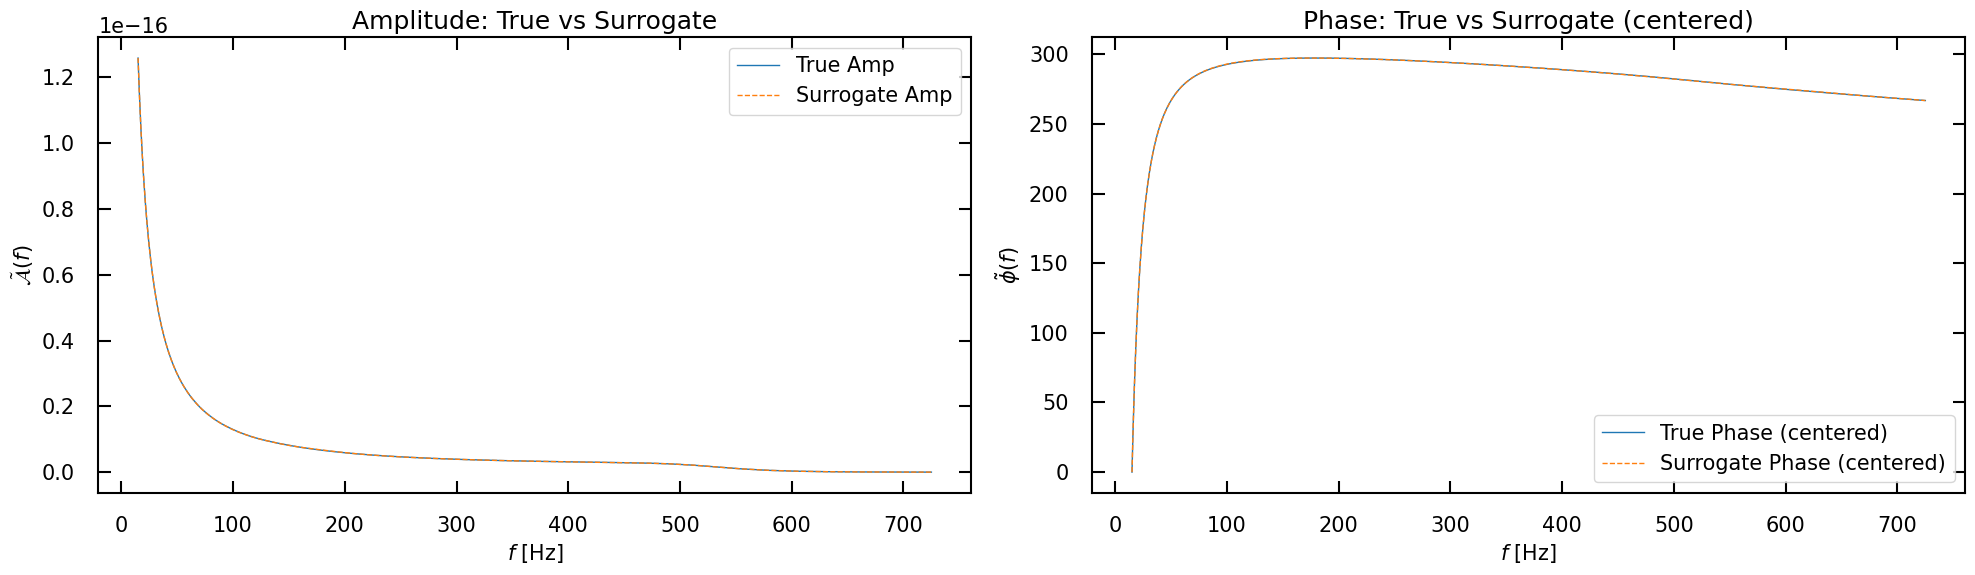

In [16]:
plt.figure(figsize=(20,6))
plt.subplot(1,2,1)
plt.plot(freq_amp, true_amp, label='True Amp')
plt.plot(freq_amp, amp_rec_scaled, '--', label='Surrogate Amp')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$\mathcal{\tilde{A}}(f)$')
plt.title('Amplitude: True vs Surrogate')
plt.legend()

plt.subplot(1,2,2)
plt.plot(freq_phase, true_phase_centered, label='True Phase (centered)')
plt.plot(freq_phase, phase_rec, '--', label='Surrogate Phase (centered)')
plt.xlabel(r'$f$ [Hz]')
plt.ylabel(r'$\tilde{\phi}(f)$')
plt.title('Phase: True vs Surrogate (centered)')
plt.legend()
plt.tight_layout()
plt.show()